# Football Match Analysis — Player Detection, Tracking & Team Classification

**Match:** FK Budućnost vs FK Sutjeska — Montenegro 1.CFL, Round 20 (21.02.2026)  
**Model:** YOLOv8n fine-tuned on 300 labeled frames (player, ball, goalkeeper, referee)

## Pipeline
1. **Detect** players and ball using fine-tuned YOLOv8 + ByteTrack
2. **Classify** teams via jersey color extraction (KMeans on HSV)
3. **Annotate** with team-colored ellipses, ball triangles, and track IDs
4. **Export** annotated video

In [14]:
import sys
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import importlib

# Ensure src is importable
sys.path.insert(0, str(Path.cwd()))

import src.config, src.video_utils, src.detection, src.team_classifier, src.tracking, src.visualization
for mod in [src.config, src.video_utils, src.detection, src.team_classifier, src.tracking, src.visualization]:
    importlib.reload(mod)

from src.config import Config
from src.video_utils import extract_clip, open_video, get_video_info, create_video_writer
from src.detection import PlayerDetector
from src.team_classifier import TeamClassifier
from src.tracking import Tracker
from src.visualization import Annotator

print("All modules loaded successfully.")

All modules loaded successfully.


In [15]:
# Load test clip
clip_path = Config.TEST_CLIP
cap = open_video(clip_path)
info = get_video_info(cap)
cap.release()
print(f"{clip_path.name}: {info['width']}x{info['height']} @ {info['fps']}fps, {info['total_frames']} frames")

test_clip_5min.mp4: 1920x1080 @ 25.0fps, 7520 frames


## 1. Detection Preview

Players detected: 19
Ball detected: 1


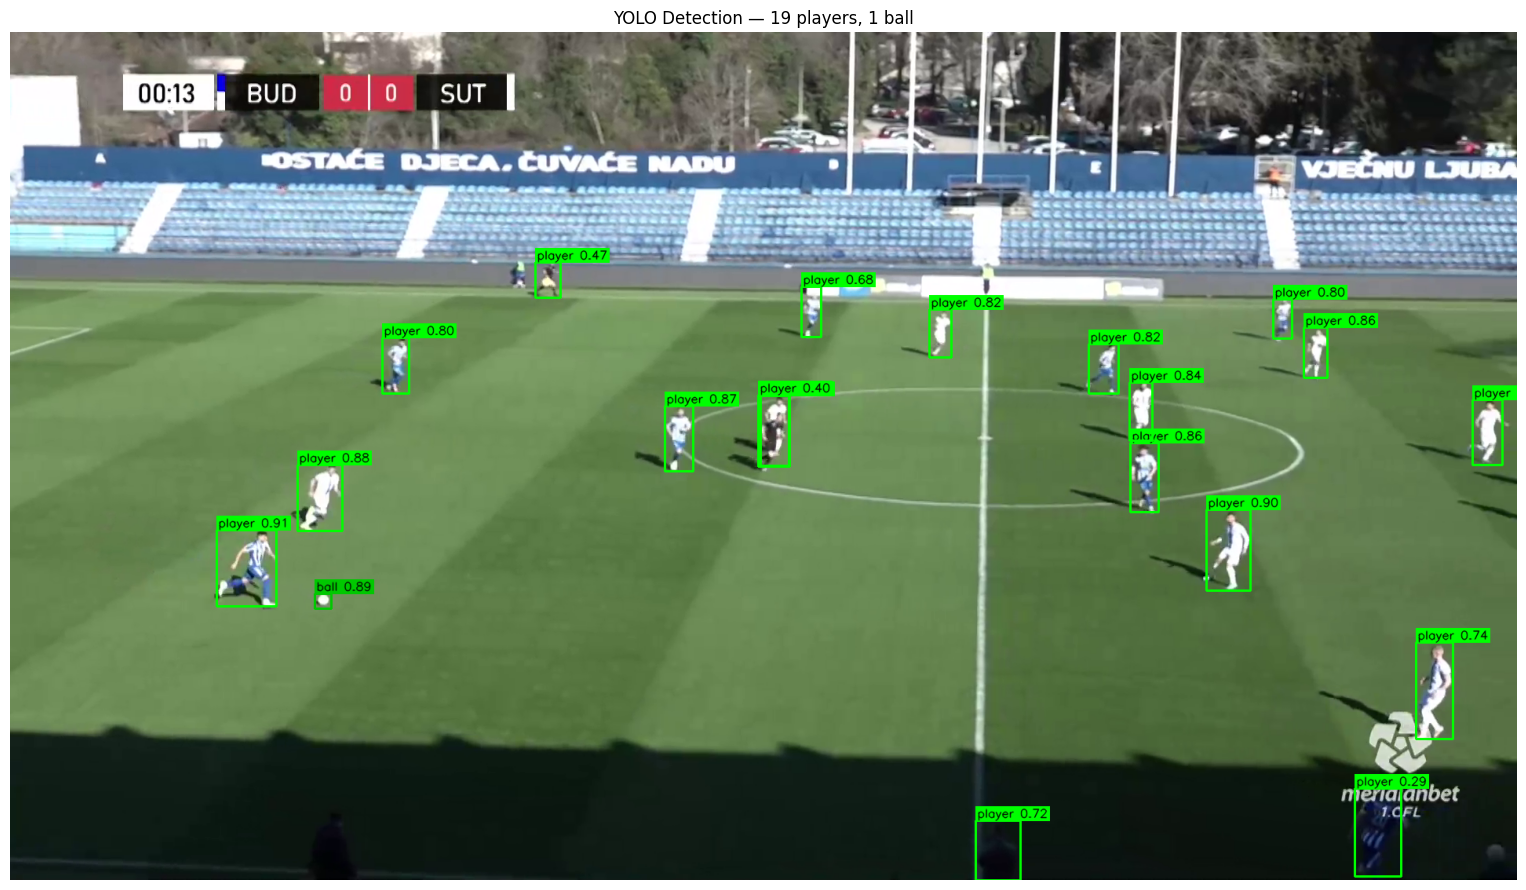

In [16]:
detector = PlayerDetector()

cap = open_video(clip_path)
# Skip ahead 30 seconds to get a good gameplay frame
cap.set(cv2.CAP_PROP_POS_FRAMES, int(info['fps'] * 15))
ret, frame = cap.read()
cap.release()

detections = detector.detect(frame)
print(f"Players detected: {len(detections['players'])}")
print(f"Ball detected: {len(detections['ball'])}")

# Show debug annotation
annotator = Annotator()
debug_frame = annotator.annotate_frame_debug(frame, detections)

plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(debug_frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'YOLO Detection — {len(detections["players"])} players, {len(detections["ball"])} ball')
plt.tight_layout()
plt.show()

## 2. Appearance Embedding Collection

Sample every N-th frame to collect ResNet18 appearance embeddings for KMeans clustering.

In [ ]:
team_clf = TeamClassifier()
all_embeddings = []

SAMPLE_EVERY_N = 15  # sample every 15th frame

cap = open_video(clip_path)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_idx = 0

print(f"Collecting appearance embeddings from {total // SAMPLE_EVERY_N} sampled frames...")

for _ in tqdm(range(total), desc="Extracting embeddings", total=total):
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % SAMPLE_EVERY_N == 0:
        detections = detector.detect(frame)
        embs = team_clf.collect_embeddings(frame, detections['players'])
        all_embeddings.extend(embs)

    frame_idx += 1

cap.release()
all_embeddings = np.array(all_embeddings)
print(f"\nCollected {len(all_embeddings)} embeddings ({all_embeddings.shape[1]}-dim each)")

Sampling colors:   0%|          | 0/7520 [00:00<?, ?it/s]

Sampling colors: 100%|██████████| 7520/7520 [02:06<00:00, 59.31it/s]


Collected 5523 jersey color samples


## 3. Fit & Visualize Team Clusters

In [37]:
from sklearn.decomposition import PCA

team_clf.fit(all_embeddings)

# Reduce 512-dim embeddings to 3D for visualization
pca = PCA(n_components=3, random_state=42)
coords_3d = pca.fit_transform(all_embeddings)

labels = team_clf.kmeans.predict(all_embeddings)
team_ids = [team_clf.cluster_to_team[c] for c in labels]

var = pca.explained_variance_ratio_
print(f"PCA variance explained: PC1={var[0]:.1%}, PC2={var[1]:.1%}, PC3={var[2]:.1%} (total={sum(var):.1%})")

Team classification fitted on 5523 field player embeddings
  Cluster distribution: {np.int32(1): 2644, np.int32(0): 2879}
PCA variance explained: PC1=10.4%, PC2=9.0%, PC3=6.5% (total=25.9%)


### Interactive Cluster Explorer

Hover over points to see the jersey crop that produced each color sample.

In [38]:
import plotly.graph_objects as go
import base64, io
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

# --- Collect embeddings + thumbnail crops ---
viz_embeddings = []
crop_images_b64 = []
THUMB_W, THUMB_H = 48, 72
INTERACTIVE_SAMPLE_EVERY = 45

cap = open_video(clip_path)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_idx = 0

print(f"Collecting crops + embeddings from ~{total // INTERACTIVE_SAMPLE_EVERY} frames...")

for _ in tqdm(range(total), desc="Collecting", total=total):
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % INTERACTIVE_SAMPLE_EVERY == 0:
        dets = detector.detect(frame)
        field_players = [p for p in dets['players']
                         if p.get('cls_id', 0) == team_clf.CLS_PLAYER]
        if field_players:
            bboxes = [p['bbox'] for p in field_players]
            embs = team_clf.extract_embeddings_batch(frame, bboxes)
            viz_embeddings.extend(embs)

            for p in field_players:
                x1, y1, x2, y2 = p['bbox']
                crop = frame[y1:y2, x1:x2]
                if crop.size == 0:
                    crop_images_b64.append("")
                    continue
                crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                pil_img = Image.fromarray(crop_rgb).resize((THUMB_W, THUMB_H), Image.LANCZOS)
                buf = io.BytesIO()
                pil_img.save(buf, format='PNG')
                crop_images_b64.append(base64.b64encode(buf.getvalue()).decode('utf-8'))

    frame_idx += 1

cap.release()
viz_embeddings = np.array(viz_embeddings)
print(f"Collected {len(viz_embeddings)} samples with crops")

# --- Project to 3D with PCA ---
viz_3d = pca.transform(viz_embeddings)
pred_labels = team_clf.kmeans.predict(viz_embeddings)
pred_team_ids = [team_clf.cluster_to_team[c] for c in pred_labels]
team_names_map = {0: 'Team A', 1: 'Team B'}
team_hex = {0: '#3498db', 1: '#f1c40f'}

# --- Plotly FigureWidget with hover crop preview ---
fig = go.FigureWidget()

for tid, tname in team_names_map.items():
    mask = [i for i, t in enumerate(pred_team_ids) if t == tid]
    fig.add_trace(go.Scatter3d(
        x=viz_3d[mask, 0],
        y=viz_3d[mask, 1],
        z=viz_3d[mask, 2],
        mode='markers',
        marker=dict(size=2, color=team_hex[tid], opacity=0.5),
        name=tname,
        customdata=mask,
        hovertemplate=(
            f'<b>{tname}</b><br>'
            'PC1=%{x:.1f}<br>PC2=%{y:.1f}<br>PC3=%{z:.1f}'
            '<extra></extra>'
        ),
    ))

# Cluster centers
centers_3d = pca.transform(team_clf.kmeans.cluster_centers_)
for cid, c3d in enumerate(centers_3d):
    tid = team_clf.cluster_to_team[cid]
    fig.add_trace(go.Scatter3d(
        x=[c3d[0]], y=[c3d[1]], z=[c3d[2]],
        mode='markers+text',
        marker=dict(size=8, color=team_hex[tid], symbol='x',
                    line=dict(width=2, color='black')),
        text=[team_names_map[tid]],
        showlegend=False,
    ))

var = pca.explained_variance_ratio_
fig.update_layout(
    title='3D Team Clusters — ResNet18 Embeddings (PCA)',
    scene=dict(
        xaxis_title=f'PC1 ({var[0]:.1%})',
        yaxis_title=f'PC2 ({var[1]:.1%})',
        zaxis_title=f'PC3 ({var[2]:.1%})',
    ),
    width=800, height=650,
    margin=dict(l=0, r=0, t=40, b=0),
)

# --- Hover image panel ---
crop_widget = widgets.Image(format='png', width=96, height=144,
                            layout=widgets.Layout(border='1px solid #ccc'))
label_widget = widgets.HTML(value='<i>Hover over a point to see the player crop</i>')

# Set a blank placeholder image
_blank = Image.new('RGB', (THUMB_W, THUMB_H), (220, 220, 220))
_buf = io.BytesIO()
_blank.save(_buf, format='PNG')
crop_widget.value = _buf.getvalue()

def make_hover_handler():
    def handler(trace, points, state):
        if points.point_inds:
            local_idx = points.point_inds[0]
            if trace.customdata is not None:
                global_idx = int(trace.customdata[local_idx])
                if 0 <= global_idx < len(crop_images_b64) and crop_images_b64[global_idx]:
                    crop_widget.value = base64.b64decode(crop_images_b64[global_idx])
                    label_widget.value = f'<b>{trace.name}</b> — sample #{global_idx}'
    return handler

_handler = make_hover_handler()
for trace in fig.data:
    if hasattr(trace, 'customdata') and trace.customdata is not None:
        trace.on_hover(_handler)

display(widgets.HBox([
    fig,
    widgets.VBox([label_widget, crop_widget],
                 layout=widgets.Layout(padding='20px', align_items='center',
                                       justify_content='center'))
]))

Collecting: 100%|██████████| 7520/7520 [01:25<00:00, 87.71it/s] 


Collected 1854 samples with crops


    'data': [{'customdata': [3, 5, 6, ..., 1848, 1850, 1853],
              'hov…

## 4. Full Pipeline — Annotate & Export

Class distribution: {'player': 16, 'referee': 2}
Team distribution: {'Team A': 15, 'Team B': 1, 'Referee': 2}


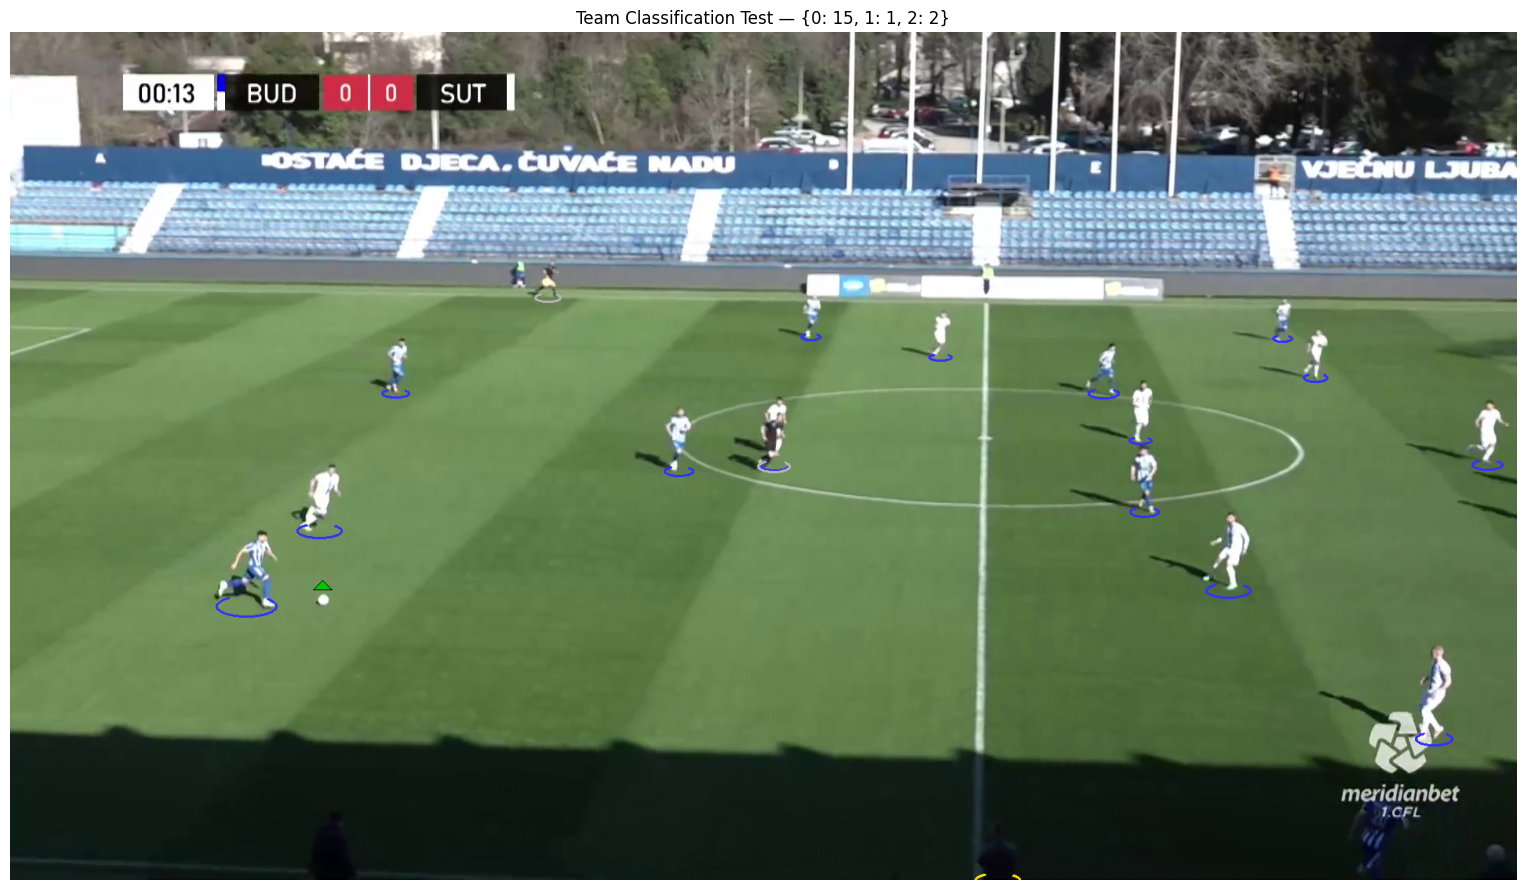

In [ ]:
# Quick single-frame test: classify players and show team assignments
cap = open_video(clip_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, int(info['fps'] * 15))
ret, test_frame = cap.read()
cap.release()

test_dets = detector.detect(test_frame)

# Show cls_id distribution
from collections import Counter
cls_counts = Counter(p['cls_id'] for p in test_dets['players'])
print(f"Class distribution: { {['player','ball','goalkeeper','referee'][k]: v for k,v in cls_counts.items()} }")

# Classify using ResNet embeddings
team_clf.classify_players(test_frame, test_dets['players'])
team_counts = Counter(p['team_id'] for p in test_dets['players'])
team_names = {0: 'Team A', 1: 'Team B', 2: 'Referee'}
print(f"Team distribution: { {team_names.get(k, f'Unknown {k}'): v for k,v in team_counts.items()} }")

# Annotate and show
annotated = annotator.annotate_frame(test_frame, test_dets)
plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Team Classification (ResNet18) — {dict(team_counts)}')
plt.tight_layout()
plt.show()

In [24]:
tracker = Tracker()
output_path = Config.OUTPUT_DIR / "annotated_5min.mp4"

cap = open_video(clip_path)
info = get_video_info(cap)
writer = create_video_writer(output_path, info['fps'], info['width'], info['height'])

total_frames = info['total_frames']
frame_idx = 0

print(f"Processing {total_frames} frames → {output_path.name}")

for _ in tqdm(range(total_frames), desc="Annotating"):
    ret, frame = cap.read()
    if not ret:
        break

    # Detect + track
    detections = detector.detect_with_tracking(frame)

    # Classify teams using cls_id-based routing + temporal smoothing
    team_clf.classify_players(frame, detections['players'])
    for p in detections['players']:
        p['team_id'] = tracker.get_stable_team(p['track_id'], p['team_id'])

    # Annotate
    annotated = annotator.annotate_frame(frame, detections)
    writer.write(annotated)

    frame_idx += 1

writer.release()
cap.release()

print(f"\nDone! Output saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / 1e6:.1f} MB")
print(f"Unique tracks: {len(tracker.track_team_history)}")

Processing 7520 frames → annotated_5min.mp4


Annotating:   1%|          | 68/7520 [00:08<15:56,  7.79it/s]


KeyboardInterrupt: 

## 5. Preview Output

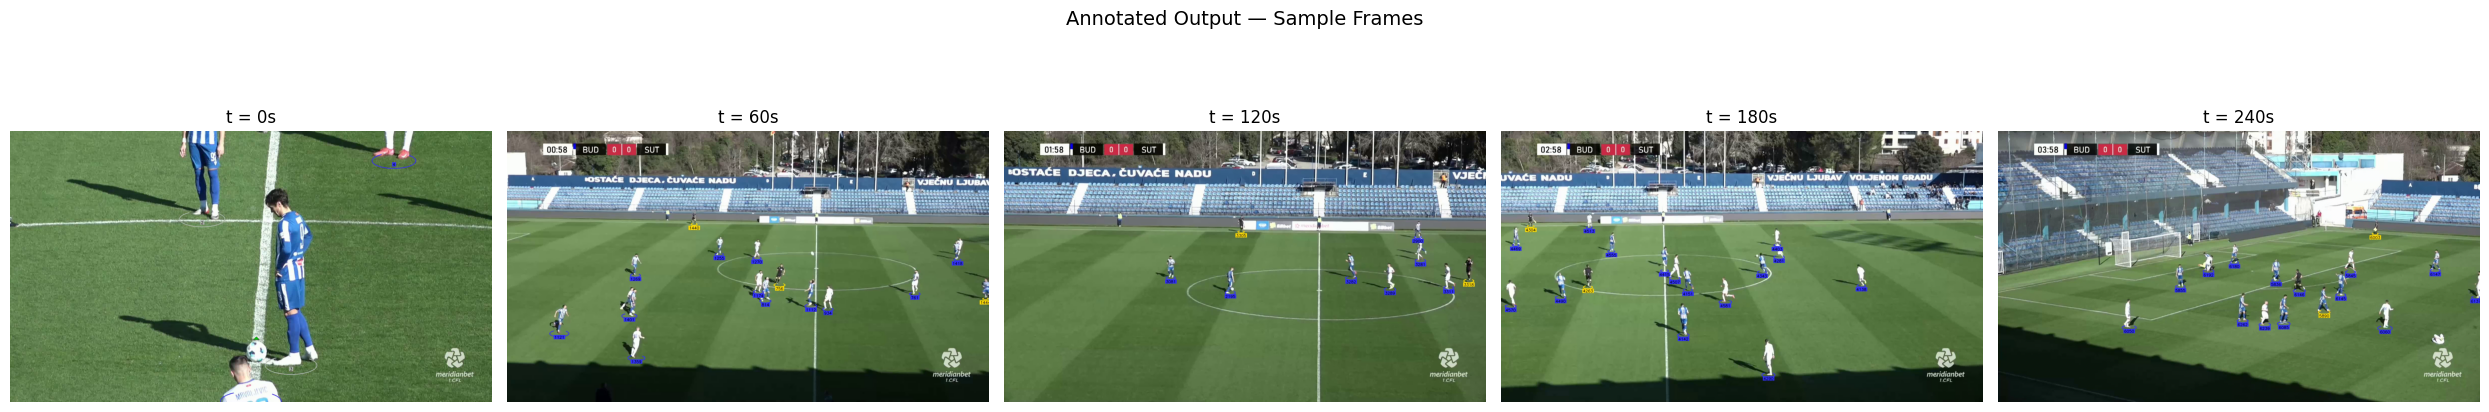

In [ ]:
cap = open_video(output_path)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Show frames at 0s, 60s, 120s, 180s, 240s
timestamps = [0, 60, 120, 180, 240]

fig, axes = plt.subplots(1, len(timestamps), figsize=(25, 5))

for i, t in enumerate(timestamps):
    frame_num = min(int(t * fps), total - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    if ret:
        axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f't = {t}s')
    axes[i].axis('off')

cap.release()
plt.suptitle('Annotated Output — Sample Frames', fontsize=14)
plt.tight_layout()
plt.show()

## Known Issues & Next Steps

### Current limitations
- **Ball detection** — Poor on wide-angle shots (ball is ~15px, motion-blurred). Works on close-ups only. Consider TrackNet or temporal interpolation.
- **Team classification** — HSV KMeans struggles when both teams have similar jersey colors. Need better feature extraction or a learned approach.
- **Track ID switches** — ByteTrack loses IDs during close player interactions. Appearance-based ReID (BoT-SORT) would help.

### Next steps
- Improve ball detection (TrackNet / lower threshold + interpolation)
- Improve team classification (contrastive learning / supervised approach)
- Homography estimation — map pixel → pitch coordinates
- Player speed & distance from pitch coordinates
- Scale to full match and league (GPU)